CSV files loaded
plot_df head:
              Day  Actual_Demand  Predicted_Demand
251214     Monday     4384.11000       5572.467519
241594     Friday     5391.08000       5649.709747
310910   Thursday     5939.50000       5732.459675
21082   Wednesday     5104.99167       5711.986260
317764     Sunday     4593.71000       4883.275644
plot_df shape: (75537, 3)
Unique days in plot_df: ['Monday', 'Friday', 'Thursday', 'Wednesday', 'Sunday', 'Tuesday', 'Saturday']
Categories (7, object): ['Monday' < 'Tuesday' < 'Wednesday' < 'Thursday' < 'Friday' < 'Saturday' < 'Sunday']


C:\Users\Coder\AppData\Local\Temp\ipykernel_17668\2086370532.py:71: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


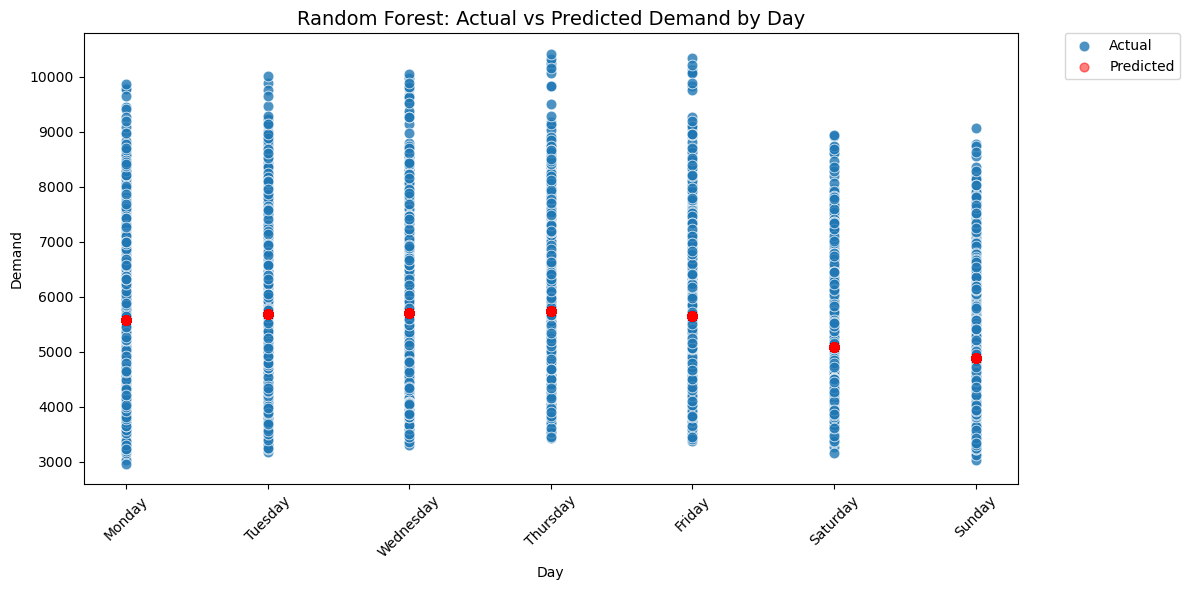

In [35]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import glob
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load data
demand = glob.glob("/Users/Coder/Desktop/ADS1002-project/data/processed/VIC_clean.csv")
demand.sort()
df_list = [pd.read_csv(f) for f in demand]
if df_list:
    print("CSV files loaded")
else:
    print("No CSV files were loaded.")
df = pd.concat(df_list, ignore_index=True)

# Parse datetime column
df['Datetime'] = df['Datetime'].str.replace(r'\+.*$', '', regex=True)
df['Datetime'] = pd.to_datetime(df['Datetime'], format="%Y-%m-%d %H:%M:%S")

# Extract features
df['Hour'] = df['Datetime'].dt.hour
df['Year'] = df['Datetime'].dt.year
df['Day'] = df['Datetime'].dt.day_name()  # Day of week

# Data separation as X and Y
x = pd.get_dummies(df['Day'])  # One-hot encode day of week
y = df['Total Demand']

# Data splitting
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=100)

# Model building with Random Forest
rf = RandomForestRegressor()
rf.fit(X_train, Y_train)

# Predictions
y_rf_train_pred = rf.predict(X_train)
y_rf_test_pred = rf.predict(X_test)

# Model performance
rf_train_mse = mean_squared_error(Y_train, y_rf_train_pred)
rf_train_r2 = r2_score(Y_train, y_rf_train_pred)
rf_test_mse = mean_squared_error(Y_test, y_rf_test_pred)
rf_test_r2 = r2_score(Y_test, y_rf_test_pred)

# Build DataFrame for plotting
plot_df = pd.DataFrame({
    "Day": X_test.idxmax(axis=1),  # Get the day name from one-hot encoded columns
    "Actual_Demand": Y_test.values,
    "Predicted_Demand": y_rf_test_pred
})

# Ensure 'Day' is categorical
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plot_df["Day"] = pd.Categorical(plot_df["Day"], categories=day_order, ordered=True)

# Debug: Print DataFrame to verify
print("plot_df head:")
print(plot_df.head())
print("plot_df shape:", plot_df.shape)
print("Unique days in plot_df:", plot_df["Day"].unique())

# Create the plot
plt.figure(figsize=(12, 6))

# Scatter plot of actual values
sns.scatterplot(
    data=plot_df,
    x="Day",
    y="Actual_Demand",
    palette="tab10",
    s=60,
    alpha=0.8,
    label="Actual"
)

# Scatter plot of predicted values
plt.scatter(
    x=plot_df["Day"],
    y=plot_df["Predicted_Demand"],
    color="red",
    s=40,
    alpha=0.5,
    label="Predicted"
)

# Title & labels
plt.title("Random Forest: Actual vs Predicted Demand by Day", fontsize=14)
plt.xlabel("Day")
plt.ylabel("Demand")
plt.xticks(rotation=45)

# Move legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0)

plt.tight_layout()
plt.show()